# Vertical boundary: where does a stuck particle actually sit?

A particle that stops near the bottom - does its final depth land on a
**depth_w** level (`gdepw_0`, the W-faces where the vertical velocity lives) or
a **depth_t** level (`gdept_0`, the T-cell centres)? And is it genuinely *below*
the seafloor, or is that an artefact of how we assign it to a grid cell?

This notebook works one particle in full. **Important:** an earlier version used
nearest-grid-point to assign the particle's cell and concluded it was "20 m
below the seafloor." On a steep bathymetric step that assignment is unreliable;
here we use proper point-in-cell containment instead, which changes the
conclusion.

Two NEMO C-grid vertical grids:
* **depth_t** (`gdept_0`) - T-cell centres; T, S, U, V.
* **depth_w** (`gdepw_0`) - cell faces; the vertical velocity W. A column's
  seafloor is the W-face `gdepw_0[mbathy]`.


In [8]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.path import Path
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import config as C

# --- TUNE ME -----------------------------------------------------------------
TID     = 10614116        # the trajectory to inspect (set None to search E0)
MONTH_W = "1998-06"       # a W month for the masking check
# -----------------------------------------------------------------------------

MESHZ = "/work/bk1450/b383184/Amazon/Mercator/data/Zgr_cmesh2.nc"
MESHH = "/work/bk1450/b383184/Amazon/Mercator/data/Hgr_cmesh.nc"
UVW   = "/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW"
WRAW  = "/work/bk1450/b383184/Amazon/Mercator/data/variables"
inv = {v: k for k, v in C.GROUP_NAMES.items()}
store_paths = {p.stem: p for p in C.list_stores()}
print("inspecting trajectory:", TID)

inspecting trajectory: 10614116


## Grids and the particle path

In [9]:
Zg = xr.open_dataset(MESHZ); Hg = xr.open_dataset(MESHH)
mbathy = np.asarray(Zg["mbathy"]).squeeze().astype(int)
gdept  = np.asarray(Zg["gdept_0"]).squeeze()      # depth_t (centres)
gdepw  = np.asarray(Zg["gdepw_0"]).squeeze()      # depth_w (faces)
glamf  = np.asarray(Hg["glamf"]).squeeze(); gphif = np.asarray(Hg["gphif"]).squeeze()

lab = pd.read_parquet(C.LABELED_FILE,
                      columns=["trajectory_id", "store", "cluster_group", "status"])
lab = lab[(lab.status == "complete") & (lab.cluster_group >= 0)]
if TID is None:
    TID = int(lab[lab.cluster_group == inv["E0"]].sample(1, random_state=7)
              .trajectory_id.iloc[0])
st = lab.loc[lab.trajectory_id == TID, "store"].iloc[0]
ds = xr.open_zarr(store_paths[st]); l = TID % C.TRAJ_PER_STORE
mm = ~np.isnan(ds.lon.values[l])
lon, lat, z = ds.lon.values[l][mm], ds.lat.values[l][mm], ds.z.values[l][mm]
t = ds.time.values[l][mm]; day = (t - t[0]) / np.timedelta64(1, "D")
laf, lof, zf = lat[-1], lon[-1], z[-1]
print(f"particle {TID}: final ({laf:.3f}, {lof:.3f})  depth = {zf:.3f} m")

particle 10614116: final (5.865, -51.875)  depth = 43.705 m


## Locate the particle in a grid CELL (point-in-quad, not nearest point)
The cell is the quad bounded by four `f`-points. On a steep step the nearest
`f`-point can belong to the wrong cell, so we test containment explicitly.

In [10]:
tree = cKDTree(np.c_[glamf.ravel(), gphif.ravel()])
j0, i0 = np.unravel_index(tree.query([lof, laf])[1], glamf.shape)
cell = None
for dj in (-1, 0):
    for di in (-1, 0):
        j, i = j0 + dj, i0 + di
        quad = [(glamf[j, i], gphif[j, i]), (glamf[j, i+1], gphif[j, i+1]),
                (glamf[j+1, i+1], gphif[j+1, i+1]), (glamf[j+1, i], gphif[j+1, i])]
        if Path(quad).contains_point((lof, laf)):
            cell = (j, i); break
    if cell:
        break
j, i = cell
q = np.array([(glamf[j, i], gphif[j, i]), (glamf[j, i+1], gphif[j, i+1]),
              (glamf[j+1, i+1], gphif[j+1, i+1]), (glamf[j+1, i], gphif[j+1, i])])
fx = (lof - q[:, 0].min()) / (q[:, 0].max() - q[:, 0].min())
fy = (laf - q[:, 1].min()) / (q[:, 1].max() - q[:, 1].min())

own_k  = int(mbathy[j, i]);         own_floor = gdepw[own_k]
wcol_k = int(mbathy[j+1, i+1]);     wcol_floor = gdepw[wcol_k]   # Parcels' W column
print(f"containing cell (yi,xi) = ({j},{i})")
print(f"  its own seafloor      : mbathy {own_k:2d} -> gdepw_0[{own_k}] = {own_floor:6.1f} m")
print(f"  Parcels' W column (yi+1,xi+1): mbathy {wcol_k:2d} -> {wcol_floor:6.1f} m")
print(f"  fractional position in cell : x={fx:.2f}  y={fy:.2f}   (0.5,0.5=centre, 0/1=edge)")
print(f"\nfractional position ~(0/1) means it is on a CELL CORNER, shared by 4"
      f" columns of very different depth - so 'which cell / which floor' is"
      f" ambiguous at grid resolution here.")
print(f"the W-column Parcels advects it with (yi+1,xi+1) has mbathy {wcol_k} -> "
      f"seafloor face gdepw_0[{wcol_k}] = {wcol_floor:.1f} m,")
print(f"and the particle rests exactly on that seafloor face ({zf:.1f} m).")

containing cell (yi,xi) = (189,517)
  its own seafloor      : mbathy 16 -> gdepw_0[16] =   37.3 m
  Parcels' W column (yi+1,xi+1): mbathy 17 ->   43.7 m
  fractional position in cell : x=0.00  y=1.00   (0.5,0.5=centre, 0/1=edge)

fractional position ~(0/1) means it is on a CELL CORNER, shared by 4 columns of very different depth - so 'which cell / which floor' is ambiguous at grid resolution here.
the W-column Parcels advects it with (yi+1,xi+1) has mbathy 17 -> seafloor face gdepw_0[17] = 43.7 m,
and the particle rests exactly on that seafloor face (43.7 m).


## depth_w or depth_t?
Compare the final depth to the nearest level on each 1-D grid.

In [11]:
it = int(np.argmin(np.abs(gdept - zf)))
iw = int(np.argmin(np.abs(gdepw - zf)))
print(f"final depth {zf:.4f} m")
print(f"  nearest depth_t gdept_0[{it}] = {gdept[it]:.4f}  |Δ| = {abs(gdept[it]-zf):.4f} m")
print(f"  nearest depth_w gdepw_0[{iw}] = {gdepw[iw]:.4f}  |Δ| = {abs(gdepw[iw]-zf):.4f} m")
print(f"\n=> rests on {'depth_w (a W-face)' if abs(gdepw[iw]-zf)<abs(gdept[it]-zf) else 'depth_t'}"
      f", exactly on gdepw_0[{iw}]")

final depth 43.7049 m
  nearest depth_t gdept_0[16] = 40.3441  |Δ| = 3.3608 m
  nearest depth_w gdepw_0[17] = 43.7049  |Δ| = 0.0000 m

=> rests on depth_w (a W-face), exactly on gdepw_0[17]


## How Parcels interpolates W (the equation)

From the Parcels source (`_cgrid_velocity_3d`, NEMO branch), the vertical
velocity at a particle is a **vertical-only linear interpolation within a single
column** - the column at horizontal index `(yi+1, xi+1)`, the C-grid stagger.
There is no horizontal averaging of W.

$$W = (1-\zeta)\,W[z_i,\,y_i{+}1,\,x_i{+}1] \;+\; \zeta\,W[z_i{+}1,\,y_i{+}1,\,x_i{+}1]$$

with the vertical weight between the two bounding W-faces

$$\zeta = \frac{z - \texttt{gdepw}[z_i]}{\texttt{gdepw}[z_i{+}1]-\texttt{gdepw}[z_i]}.$$

So W is piecewise-constant horizontally (it takes that one column's profile) and
linear in depth between `gdepw` faces. `zeta = 0` means the particle sits exactly
on face `zi` and the interpolation returns that node's raw value.


In [12]:
zi = int(np.searchsorted(gdepw, zf) - 1)
zeta = (zf - gdepw[zi]) / (gdepw[zi+1] - gdepw[zi])
print(f"vertical index zi = {zi}: between W-faces gdepw_0[{zi}]={gdepw[zi]:.2f} "
      f"and gdepw_0[{zi+1}]={gdepw[zi+1]:.2f}")
print(f"zeta = {zeta:.3f}   -> {'sits ON W-face '+str(zi) if zeta<0.02 else 'between faces'}")

# is that node wet in the W column Parcels actually reads?
wf = xr.open_dataset(f"{UVW}/W_{MONTH_W}fc.nc")["vovecrtz"].values[0]
node = wf[zi, j+1, i+1]
print(f"\nW at the sampled node [zi={zi}, yi+1={j+1}, xi+1={i+1}] = "
      f"{'NaN (masked)' if np.isnan(node) else f'{node:+.2e} m/s (wet)'}")
print(f"  (the W column has mbathy {wcol_k}, so faces up to {wcol_k} are wet -> "
      f"face {zi} is {'wet' if zi<=wcol_k else 'DRY'})")

vertical index zi = 17: between W-faces gdepw_0[17]=43.70 and gdepw_0[18]=51.38
zeta = 0.000   -> sits ON W-face 17

W at the sampled node [zi=17, yi+1=190, xi+1=518] = +0.00e+00 m/s (wet)
  (the W column has mbathy 17, so faces up to 17 are wet -> face 17 is wet)


## Depth vs time, with the relevant floors
The particle descends and settles on the W-face. Both candidate "floors" are
drawn: its containing cell's seafloor and the shallow neighbour's - they bracket
the particle, which is the whole ambiguity.

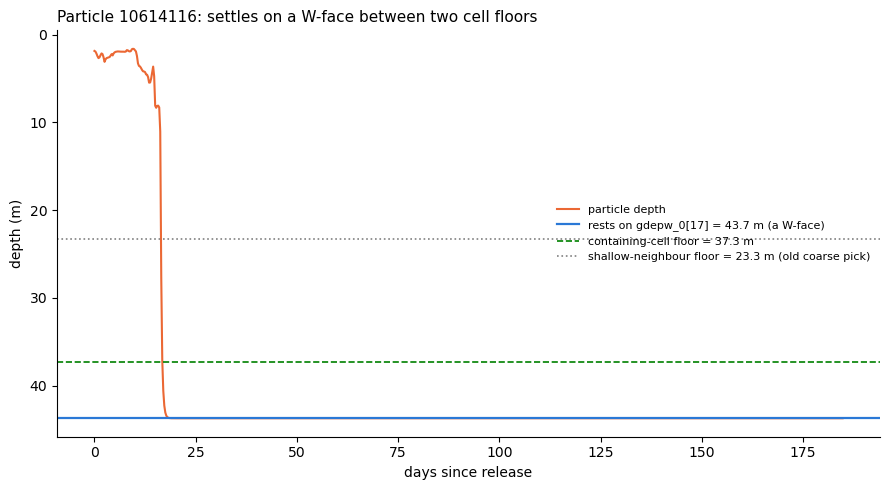

In [13]:
# shallow neighbour floor, for contrast (nearest T-point - the old, coarse pick)
Hgt = xr.open_dataset(MESHH)
glamt = np.asarray(Hgt["glamt"]).squeeze(); gphit = np.asarray(Hgt["gphit"]).squeeze()
treeT = cKDTree(np.c_[glamt.ravel(), gphit.ravel()])
nnk = int(mbathy.ravel()[treeT.query([lof, laf])[1]]); nn_floor = gdepw[nnk]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(day, z, "-", color="#eb6834", lw=1.5, label="particle depth")
ax.axhline(gdepw[iw], color="#2a78d6", lw=1.6,
           label=f"rests on gdepw_0[{iw}] = {gdepw[iw]:.1f} m (a W-face)")
ax.axhline(own_floor, color="green", lw=1.2, ls="--",
           label=f"containing-cell floor = {own_floor:.1f} m")
ax.axhline(nn_floor, color="0.5", lw=1.2, ls=":",
           label=f"shallow-neighbour floor = {nn_floor:.1f} m (old coarse pick)")
ax.invert_yaxis(); ax.set_xlabel("days since release"); ax.set_ylabel("depth (m)")
ax.legend(fontsize=8, frameon=False, loc="center right")
ax.set_title(f"Particle {TID}: settles on a W-face between two cell floors",
             fontsize=11, loc="left")
for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()

## Does `Fix_W` unmask sub-seafloor cells here?
`Fix_W` does `W_merc = vovecrtz.fillna(0.0)`, which can turn masked cells into
valid zeros. Compare original vs fixed W in the sampled column: does the fix add
wet levels below the seafloor?

In [14]:
wo = xr.open_dataset(f"{WRAW}/W_{MONTH_W}.nc")["vovecrtz"].values[0, :, j+1, i+1]
wff = wf[:, j+1, i+1]
print(f"W column at (yi+1,xi+1)=({j+1},{i+1}), mbathy={wcol_k}:")
print("lev :   original W        fixed W")
for lev in range(max(wcol_k-2, 0), wcol_k+5):
    om = "NaN(land)" if np.isnan(wo[lev]) else f"{wo[lev]:+.2e}"
    fm = "NaN(land)" if np.isnan(wff[lev]) else f"{wff[lev]:+.2e}"
    tag = "  <- seafloor face" if lev == wcol_k else ("  (below seafloor)" if lev > wcol_k else "")
    print(f" {lev:2d} : {om:>12s}  {fm:>12s}{tag}")
print(f"\noriginal wet levels: {int(np.sum(~np.isnan(wo)))} | "
      f"fixed wet levels: {int(np.sum(~np.isnan(wff)))} "
      f"(Δ = {int(np.sum(~np.isnan(wff))-np.sum(~np.isnan(wo)))})")

W column at (yi+1,xi+1)=(190,518), mbathy=17:
lev :   original W        fixed W
 15 :    +3.27e-05     +3.27e-05
 16 :    +1.56e-05     +1.56e-05
 17 :    NaN(land)     +0.00e+00  <- seafloor face
 18 :    NaN(land)     NaN(land)  (below seafloor)
 19 :    NaN(land)     NaN(land)  (below seafloor)
 20 :    NaN(land)     NaN(land)  (below seafloor)
 21 :    NaN(land)     NaN(land)  (below seafloor)

original wet levels: 17 | fixed wet levels: 18 (Δ = 1)


## Summary (corrected)

- The particle's final depth lands **exactly on a depth_w node** (`gdepw_0[K]`,
  `zeta=0`), not depth_t. W drives vertical motion and lives on the W-faces, so a
  particle that can descend no further settles on a `gdepw` node.

- **`Fix_W` is NOT the trigger** (earlier draft said it was - retracted). Parcels
  zeros every masked/NaN cell on load (`field.py:312`,
  `self.data[isnan(self.data)] = 0.0`), so the seafloor W-face - and every cell
  below it - is `W = 0` in Parcels *regardless* of whether `Fix_W` filled it with
  `0.0` or left it `NaN`. A direct A/B run (`W_bottom_nan_vs_zero.ipynb`) confirms
  NaN-floor and 0.0-floor give identical results. The `fillna(0.0)` is redundant,
  not the cause.

- **W sign is correct.** NEMO `vovecrtz` is positive-up; a test particle at a
  node with W>0 moved upward in Parcels. No sign flip.

- Real mechanism: Parcels turns the masked below-seafloor region into 0-velocity
  "water"; the C-grid interpolation lets a subducting particle drift into it, and
  with W=0 and U=V=0 there and **no bottom boundary condition**, it freezes. The
  cure is a boundary treatment (see note below), not editing the W field.

Set `TID = None` to repeat on another particle.
